# Similarity figures

Fig. 1a, 1c and Supplementary Fig. S1a-S1c, computed from the per-perturbation cosine audits of `compute_noise_corrected_cosine.py` (total and residual effects) and from the L1 strength scores of `1_preprocessing`. Each panel is written to `figures/` (PDF) and the values it plots to `data/` (CSV); the heatmaps of Fig. 1a, 1c and S1a share one table, with a `panel` column.

The notebook reads the frozen paper results (`results_reference/`) by default. To plot a rerun, run `bash 1_preprocessing/run.sh` and `bash 3_cross_dataset_similarity/run.sh`, then set `USE_REFERENCE=0` (or `USE_REFERENCE = False` below) to read `results/`.

In [1]:
%matplotlib inline
import io
import os
import sys
from itertools import combinations

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from scipy import stats

sys.path.insert(0, "..")  # the repository root, for utils
from utils.paths import (
    DATASET_ORDER,
    REPO_ROOT,
    SIMILARITY_RESIDUAL_AUDIT,
    SIMILARITY_TOTAL_AUDIT,
    STRENGTH_SCORES,
    paper_name,
    reference,
)

USE_REFERENCE = os.environ.get("USE_REFERENCE", "1") != "0"

SIMILARITY_TOTAL_AUDIT = reference(SIMILARITY_TOTAL_AUDIT) if USE_REFERENCE else SIMILARITY_TOTAL_AUDIT
SIMILARITY_RESIDUAL_AUDIT = reference(SIMILARITY_RESIDUAL_AUDIT) if USE_REFERENCE else SIMILARITY_RESIDUAL_AUDIT
STRENGTH_SCORES = reference(STRENGTH_SCORES) if USE_REFERENCE else STRENGTH_SCORES

FIGURES = REPO_ROOT / "3_cross_dataset_similarity" / "figures"
DATA = REPO_ROOT / "3_cross_dataset_similarity" / "data"
FIGURES.mkdir(exist_ok=True)
DATA.mkdir(exist_ok=True)

DISPLAY_DPI = 110  # inline previews only; the PDFs are vector
MM = 1.0 / 25.4
TEXT_COLOR = "#202124"
N_NON_PLURIPOTENT = 7  # the first seven datasets; the other five are pluripotent

# Heatmap order (the registry order), by paper name; the matrices and the audit
# rows below are labelled with the paper names.  VCC-subsampled-H1 is not drawn
# in any heatmap.
ORDER = [paper_name(dataset) for dataset in DATASET_ORDER]
LABELS = ORDER

# Outlined related-dataset blocks (first index, size): Replogle K562, Pan/VCC hESC, Feng iPSC.
RELATED_BLOCKS = [(0, 2), (7, 2), (9, 2)]
WARM_PALETTE = ("#fffaf5", "#fee8d2", "#fdc49a", "#fc9a73", "#ef6548", "#cf3b2e", "#8f1115")
MASKED_CELL_COLOR = "#F3F4F5"
SEPARATOR_COLOR = "#70757A"
BLOCK_OUTLINE_COLOR = "#527A9B"
# (left, right, center, label) of the context brackets above the heatmaps
CONTEXT_GROUPS = [(-0.35, 6.35, 3.0, "Non-pluripotent"), (6.65, 11.35, 9.0, "Pluripotent")]


def use_panel_style(style):
    """Start each panel from the matplotlib defaults, as each paper script did in its own process."""
    matplotlib.rcdefaults()
    matplotlib.rcParams.update(style)


def show_inline(figure, bbox_inches=None):
    buffer = io.BytesIO()
    figure.savefig(buffer, format="png", dpi=DISPLAY_DPI, bbox_inches=bbox_inches, facecolor="white")
    display(Image(data=buffer.getvalue()))


def masked_heatmap_table(matrix, labels):
    """Heatmap values as drawn, with paper labels; the masked diagonal is left empty."""
    values = matrix.to_numpy(float).copy()
    np.fill_diagonal(values, np.nan)
    return pd.DataFrame(values, index=pd.Index(labels, name="dataset"), columns=labels)

## Matched total- and residual-effect matrices

Used by Fig. 1a, 1c and S1a. The audits (`SIMILARITY_TOTAL_AUDIT`, `SIMILARITY_RESIDUAL_AUDIT`) hold, per dataset pair, audit panel and shared perturbation, the corrected energies Q = sum(x²) − sum(SE²) of both sides, the corrected-signal fractions Q / sum(x²) and the unclipped noise-corrected cosine. For each pair, the total and the residual mean use the same perturbations: those that pass in both audits (finite values, Q > 0 and fraction > 0.05 on both sides), so that a change in membership is not read as an effect of removing the factor. The cosines are clipped to [-1, 1] and averaged with equal weight; the means are kept at 12 significant digits, as in the saved paper matrices. Audit panels: A (all QC-passing perturbations, primary outcomes), C (L1-selected perturbations, primary outcomes), D (L1-selected perturbations, top-2,000 feature outcomes).

In [2]:
AUDIT_FILE = "pairwise_per_perturbation_corrected_norm_audit.csv.gz"
KEYS = ["panel", "dataset_1", "dataset_2", "perturbation"]
PASS_COLUMNS = [
    "dataset_1_corrected_norm_squared",
    "dataset_2_corrected_norm_squared",
    "dataset_1_corrected_signal_fraction",
    "dataset_2_corrected_signal_fraction",
    "would_be_noise_corrected_cosine_unclipped",
]
MIN_SIGNAL_FRACTION = 0.05


def read_audit(folder):
    """Audit rows with paper dataset names (VCC-subsampled-H1 included, for S1b)."""
    audit = pd.read_csv(folder / AUDIT_FILE, usecols=KEYS + PASS_COLUMNS + ["raw_cosine_on_se_complete_outcomes"])
    for column in ["dataset_1", "dataset_2"]:
        audit[column] = audit[column].map(paper_name)
    return audit


def corrected_pass(frame, suffix):
    """Finite values, Q > 0 and Q / sum(x^2) > 0.05 on both sides."""
    values = [frame[column + suffix].to_numpy(float) for column in PASS_COLUMNS]
    q1, q2, fraction1, fraction2, _ = values
    return (
        np.isfinite(values).all(axis=0)
        & (q1 > 0)
        & (q2 > 0)
        & (fraction1 > MIN_SIGNAL_FRACTION)
        & (fraction2 > MIN_SIGNAL_FRACTION)
    )


def matched_matrices(matched, panel):
    """Total and residual matrices of one audit panel: per pair, the mean clipped cosine over
    the perturbations that pass in both audits, in audit row order (1 on the diagonal)."""
    frame = matched.loc[matched["panel"].eq(panel)]
    joint = frame.loc[corrected_pass(frame, "_total") & corrected_pass(frame, "_residual")]
    matrices = {}
    for effect in ["total", "residual"]:
        cosine = np.clip(joint[f"would_be_noise_corrected_cosine_unclipped_{effect}"].to_numpy(float), -1.0, 1.0)
        matrix = pd.DataFrame(np.eye(len(ORDER)), index=ORDER, columns=ORDER)
        for dataset_1, dataset_2 in combinations(ORDER, 2):
            in_pair = (joint["dataset_1"].eq(dataset_1) & joint["dataset_2"].eq(dataset_2)).to_numpy()
            matrix.loc[dataset_1, dataset_2] = matrix.loc[dataset_2, dataset_1] = cosine[in_pair].mean()
        matrices[effect] = matrix.map(lambda value: float(f"{value:.12g}"))
    return matrices


total_audit = read_audit(SIMILARITY_TOTAL_AUDIT)
residual_audit = read_audit(SIMILARITY_RESIDUAL_AUDIT)
# Total and residual rows side by side, for the 12 datasets of the heatmaps.
matched = total_audit.merge(residual_audit, on=KEYS, suffixes=("_total", "_residual"))
matched = matched.loc[matched["dataset_1"].isin(ORDER) & matched["dataset_2"].isin(ORDER)]
similarity = {panel: matched_matrices(matched, panel) for panel in ["A", "C", "D"]}

## Heatmap values of Fig. 1a, 1c and S1a

One table, one row per drawn (off-diagonal) cell of the six heatmaps, in matrix order: panel, perturbation and outcome selection, effect, row dataset (`dataset_1`), column dataset (`dataset_2`) and noise-corrected cosine. Each panel below draws its own rows.

In [3]:
L1_PRIMARY = "L1-strength-selected perturbations, primary outcomes"
ALL_QC = "All QC-passing perturbations, primary outcomes"
L1_TOP2000 = "L1-strength-selected perturbations, top 2,000 feature outcomes"
HEATMAPS = [  # (panel, selection, effect, audit panel), in plotting order
    ("Fig. 1a", L1_PRIMARY, "total", "C"),
    ("Fig. 1c", L1_PRIMARY, "residual", "C"),
    ("Supplementary Fig. S1a", ALL_QC, "total", "A"),
    ("Supplementary Fig. S1a", L1_TOP2000, "total", "D"),
    ("Supplementary Fig. S1a", ALL_QC, "residual", "A"),
    ("Supplementary Fig. S1a", L1_TOP2000, "residual", "D"),
]
heatmap_values = pd.DataFrame(
    [
        {
            "panel": panel,
            "selection": selection,
            "effect": effect,
            "dataset_1": dataset_1,
            "dataset_2": dataset_2,
            "noise_corrected_cosine": similarity[audit_panel][effect].loc[dataset_1, dataset_2],
        }
        for panel, selection, effect, audit_panel in HEATMAPS
        for dataset_1 in ORDER
        for dataset_2 in ORDER
        if dataset_1 != dataset_2
    ]
)
heatmap_values.to_csv(DATA / "similarity_matrices.csv", index=False)


def heatmap(panel, selection, effect):
    """One heatmap from its rows of the table: a matrix in ORDER, 1 on the diagonal."""
    rows = heatmap_values.loc[
        heatmap_values["panel"].eq(panel)
        & heatmap_values["selection"].eq(selection)
        & heatmap_values["effect"].eq(effect)
    ]
    matrix = rows.pivot(index="dataset_1", columns="dataset_2", values="noise_corrected_cosine")
    return matrix.reindex(index=ORDER, columns=ORDER).where(~np.eye(len(ORDER), dtype=bool), 1.0)

## Fig. 1a and 1c — heatmap style

Shared by the two 12 × 12 noise-corrected cosine heatmaps (diagonal masked, color scale 0-0.70).

In [4]:
SIMILARITY_VMAX = 0.70
# Font sizes for placement at ~35% of a 183-mm page (~64 mm final width).
TICK_FONT_SIZE = 17.0
PANEL_TITLE_FONT_SIZE = 22.0
GROUP_LABEL_FONT_SIZE = 15.5
COLORBAR_FONT_SIZE = 16.5
COLORBAR_TICK_FONT_SIZE = 14.5


def similarity_theme():
    matplotlib.rcdefaults()
    sns.set_theme(
        style="white",
        context="paper",
        font="DejaVu Sans",
        rc={"font.family": "sans-serif", "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none"},
    )


def draw_similarity_heatmap(figure, matrix, axis_bounds, colorbar_bounds):
    """Heatmap and colorbar at explicit axes bounds."""
    axis = figure.add_axes(axis_bounds)
    colorbar_axis = figure.add_axes(colorbar_bounds)
    cmap = colors.LinearSegmentedColormap.from_list("warm_similarity", WARM_PALETTE, N=256)
    cmap.set_bad(MASKED_CELL_COLOR)
    values = matrix.to_numpy(float)
    axis.set_facecolor(MASKED_CELL_COLOR)
    image = axis.imshow(
        np.ma.array(values, mask=np.eye(len(values), dtype=bool)),
        cmap=cmap,
        norm=colors.Normalize(vmin=0.0, vmax=SIMILARITY_VMAX),
        interpolation="nearest",
        aspect="equal",
        origin="upper",
    )

    positions = np.arange(len(ORDER))
    axis.set_xticks(positions, LABELS)
    axis.set_yticks(positions, LABELS)
    plt.setp(axis.get_xticklabels(), rotation=42, ha="right", rotation_mode="anchor", fontsize=TICK_FONT_SIZE)
    plt.setp(axis.get_yticklabels(), rotation=0, ha="right", rotation_mode="anchor", fontsize=TICK_FONT_SIZE)
    axis.tick_params(axis="both", which="both", length=0, pad=5)
    axis.set_xlim(-0.5, len(ORDER) - 0.5)
    axis.set_ylim(len(ORDER) - 0.5, -0.5)
    axis.grid(False)
    for spine in axis.spines.values():
        spine.set_visible(False)

    # Non-pluripotent / pluripotent guides and group labels.
    axis.axvline(N_NON_PLURIPOTENT - 0.5, color=SEPARATOR_COLOR, linewidth=1.15, alpha=0.70, zorder=5)
    axis.axhline(N_NON_PLURIPOTENT - 0.5, color=SEPARATOR_COLOR, linewidth=1.15, alpha=0.70, zorder=5)
    top_transform = axis.get_xaxis_transform()
    for left, right, center, label in CONTEXT_GROUPS:
        axis.plot(
            [left, right],
            [1.018, 1.018],
            transform=top_transform,
            color="#767B80",
            linewidth=1.2,
            clip_on=False,
        )
        axis.text(
            center,
            1.032,
            label,
            transform=top_transform,
            ha="center",
            va="bottom",
            fontsize=GROUP_LABEL_FONT_SIZE,
            color="#656A70",
            clip_on=False,
        )
    for start, width in RELATED_BLOCKS:
        axis.add_patch(
            Rectangle(
                (start - 0.5, start - 0.5),
                width,
                width,
                fill=False,
                edgecolor=BLOCK_OUTLINE_COLOR,
                linewidth=1.6,
                alpha=0.95,
                joinstyle="miter",
                zorder=7,
                clip_on=False,
            )
        )

    colorbar = figure.colorbar(image, cax=colorbar_axis)
    colorbar.set_label("Noise-corrected cosine", fontsize=COLORBAR_FONT_SIZE, labelpad=16)
    colorbar.set_ticks(np.arange(0.0, SIMILARITY_VMAX + 0.001, 0.1))
    colorbar.ax.tick_params(labelsize=COLORBAR_TICK_FONT_SIZE, length=4)
    colorbar.outline.set_linewidth(0.6)
    colorbar.outline.set_edgecolor("#6C7176")

## Fig. 1a — total-effect similarity

L1-selected perturbations, primary outcomes (audit panel C): the matched total-effect matrix, from the `Fig. 1a` rows of the table.

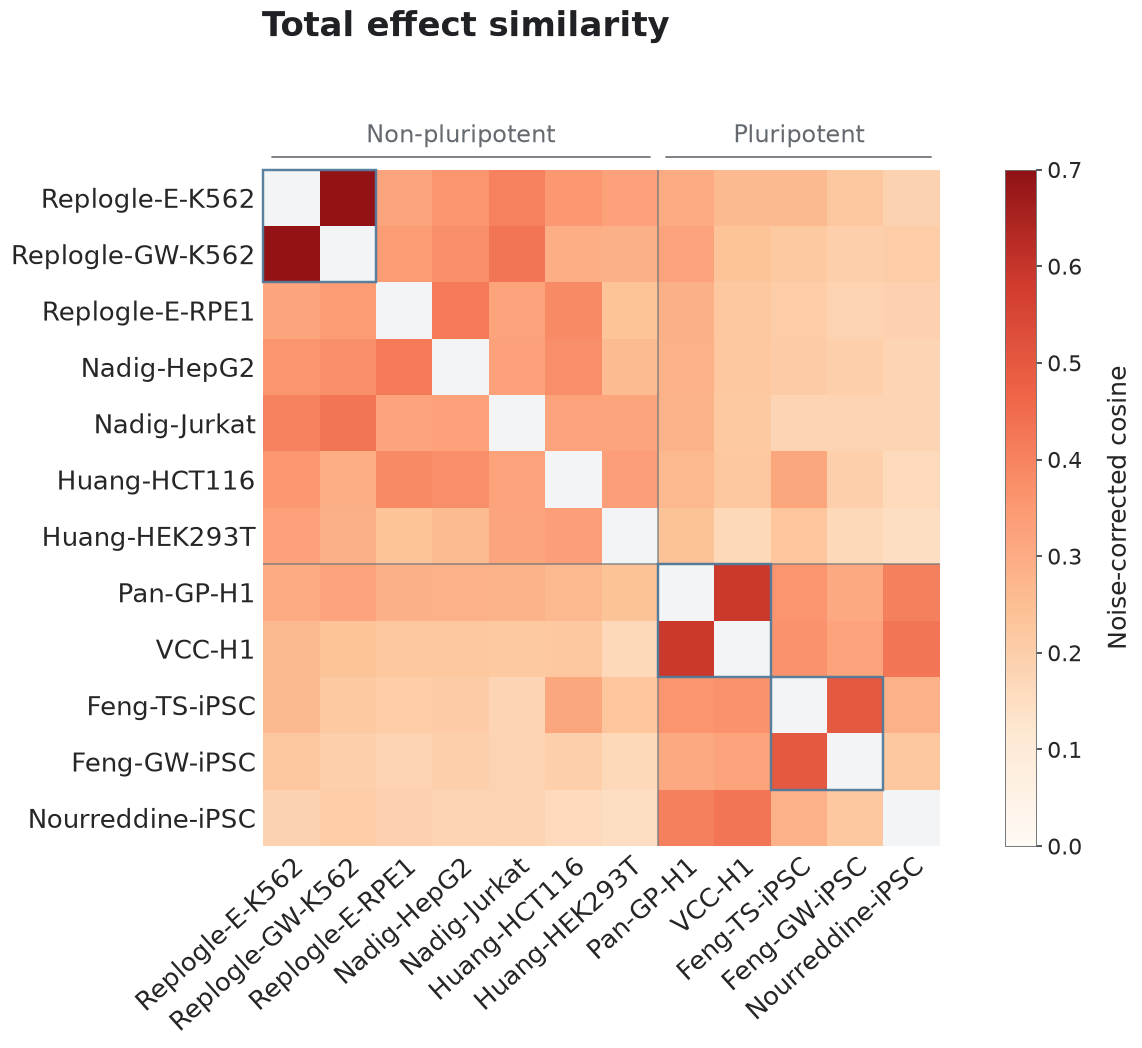

In [5]:
total = heatmap("Fig. 1a", L1_PRIMARY, "total")

similarity_theme()
figure = plt.figure(figsize=(10.5, 10.0), facecolor="white")
draw_similarity_heatmap(
    figure,
    total,
    axis_bounds=(0.225, 0.205, 0.58821, 0.615),
    colorbar_bounds=(0.86853, 0.205, 0.02647, 0.615),
)
figure.suptitle(
    "Total effect similarity",
    x=0.225,
    y=0.965,
    ha="left",
    fontsize=PANEL_TITLE_FONT_SIZE,
    fontweight="bold",
    color=TEXT_COLOR,
)

show_inline(figure, bbox_inches="tight")
figure.savefig(FIGURES / "total_effect_similarity.pdf", facecolor="white", bbox_inches="tight")
plt.close(figure)

## Fig. 1c — residual-effect similarity

Leading factor removed within each dataset (audit panel C, matched residual-effect matrix; the `Fig. 1c` rows of the table), on the Fig. 1a scale, with paired Total → Residual summaries by dataset-pair group.

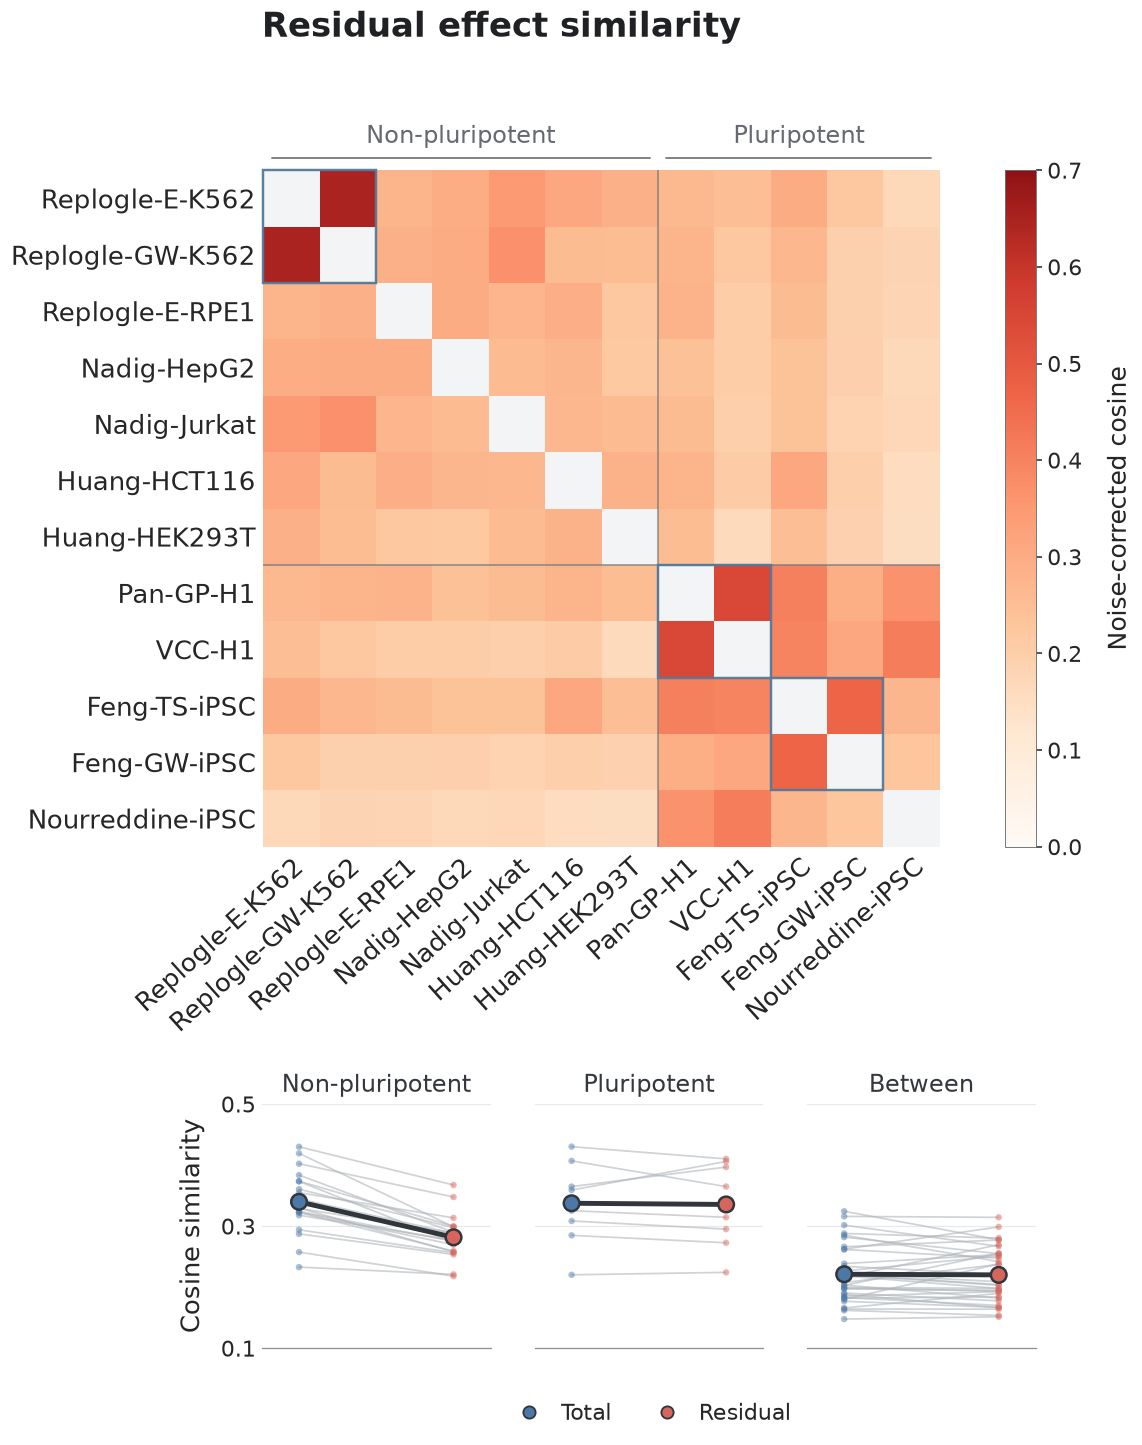

In [6]:
residual = heatmap("Fig. 1c", L1_PRIMARY, "residual")

# Paired summary: each dataset pair once, equally weighted; related pairs are left out.
PAIR_GROUP_ORDER = ["Within non-pluripotent", "Within pluripotent", "Between"]
PAIR_GROUP_TITLES = ["Non-pluripotent", "Pluripotent", "Between"]
EXCLUDED_PAIRS = {
    frozenset(("Replogle-E-K562", "Replogle-GW-K562")),
    frozenset(("Pan-GP-H1", "VCC-H1")),
    frozenset(("Feng-TS-iPSC", "Feng-GW-iPSC")),
}
non_pluripotent = set(ORDER[:N_NON_PLURIPOTENT])
rows = []
for index, dataset_1 in enumerate(ORDER):
    for dataset_2 in ORDER[index + 1 :]:
        if frozenset((dataset_1, dataset_2)) in EXCLUDED_PAIRS:
            continue
        if dataset_1 in non_pluripotent and dataset_2 in non_pluripotent:
            pair_group = "Within non-pluripotent"
        elif dataset_1 not in non_pluripotent and dataset_2 not in non_pluripotent:
            pair_group = "Within pluripotent"
        else:
            pair_group = "Between"
        rows.append(
            {
                "pair_group": pair_group,
                "dataset_1": dataset_1,
                "dataset_2": dataset_2,
                "total_cosine": float(total.loc[dataset_1, dataset_2]),
                "residual_cosine": float(residual.loc[dataset_1, dataset_2]),
            }
        )
pairs = pd.DataFrame(rows)
pair_groups = [pairs[pairs["pair_group"].eq(pair_group)] for pair_group in PAIR_GROUP_ORDER]

SUMMARY_TICK_FONT_SIZE = 14.5
SUMMARY_PAIR_COLOR = "#AEB4B9"
SUMMARY_TOTAL_COLOR = "#4C78A8"
SUMMARY_RESIDUAL_COLOR = "#D5655D"
SUMMARY_MEAN_LINE_COLOR = "#30363B"
# The 10.5 x 10-inch heatmap geometry of Fig 1a is kept and shifted up on a
# taller canvas that holds the paired summary.
HEATMAP_HEIGHT = 10.0
SUMMARY_HEIGHT = 3.45
figure_height = HEATMAP_HEIGHT + SUMMARY_HEIGHT

similarity_theme()
figure = plt.figure(figsize=(10.5, figure_height), facecolor="white")
shifted_bottom = (0.205 * HEATMAP_HEIGHT + SUMMARY_HEIGHT) / figure_height
shifted_height = 0.615 * HEATMAP_HEIGHT / figure_height
draw_similarity_heatmap(
    figure,
    residual,
    axis_bounds=(0.225, shifted_bottom, 0.58821, shifted_height),
    colorbar_bounds=(0.86853, shifted_bottom, 0.02647, shifted_height),
)
figure.suptitle(
    "Residual effect similarity",
    x=0.225,
    y=(0.965 * HEATMAP_HEIGHT + SUMMARY_HEIGHT) / figure_height,
    ha="left",
    fontsize=PANEL_TITLE_FONT_SIZE,
    fontweight="bold",
    color=TEXT_COLOR,
)

# Three aligned small multiples below the heatmap.
left, right, gap = 0.225, 0.895, 0.038
width = (right - left - 2.0 * gap) / 3.0
summary_axes = []
for group_index, (subset, title) in enumerate(zip(pair_groups, PAIR_GROUP_TITLES)):
    axis = figure.add_axes(
        (left + group_index * (width + gap), 0.070, width, 0.165), label=f"summary_{group_index}"
    )
    total_values = subset["total_cosine"].to_numpy(float)
    residual_values = subset["residual_cosine"].to_numpy(float)
    for total_value, residual_value in zip(total_values, residual_values):
        axis.plot(
            [0.0, 1.0],
            [total_value, residual_value],
            color=SUMMARY_PAIR_COLOR,
            linewidth=1.15,
            alpha=0.58,
            solid_capstyle="round",
            zorder=1,
        )
    axis.scatter(
        np.zeros_like(total_values),
        total_values,
        s=18,
        color=SUMMARY_TOTAL_COLOR,
        alpha=0.48,
        edgecolors="none",
        zorder=2,
    )
    axis.scatter(
        np.ones_like(residual_values),
        residual_values,
        s=18,
        color=SUMMARY_RESIDUAL_COLOR,
        alpha=0.48,
        edgecolors="none",
        zorder=2,
    )
    mean_total = float(total_values.mean())
    mean_residual = float(residual_values.mean())
    axis.plot(
        [0.0, 1.0],
        [mean_total, mean_residual],
        color=SUMMARY_MEAN_LINE_COLOR,
        linewidth=3.2,
        solid_capstyle="round",
        zorder=3,
    )
    axis.scatter(
        [0.0, 1.0],
        [mean_total, mean_residual],
        s=105,
        c=[SUMMARY_TOTAL_COLOR, SUMMARY_RESIDUAL_COLOR],
        edgecolors=SUMMARY_MEAN_LINE_COLOR,
        linewidths=1.6,
        zorder=4,
    )
    axis.set_xlim(-0.24, 1.24)
    axis.set_ylim(0.10, 0.50)
    axis.set_xticks([0.0, 1.0])
    axis.set_xticklabels([])
    axis.tick_params(axis="x", length=0)
    axis.set_yticks([0.10, 0.30, 0.50])
    axis.tick_params(
        axis="y", labelsize=SUMMARY_TICK_FONT_SIZE, length=0, pad=4.0, labelleft=group_index == 0
    )
    axis.set_title(title, fontsize=15.5, fontweight="normal", color="#34383C", linespacing=1.0, pad=8.0)
    axis.set_axisbelow(True)
    axis.grid(axis="y", color="#E7E9EB", linewidth=0.8)
    for side in ("top", "right", "left"):
        axis.spines[side].set_visible(False)
    axis.spines["bottom"].set_color("#8A8F94")
    axis.spines["bottom"].set_linewidth(0.8)
    summary_axes.append(axis)

summary_axes[0].set_ylabel("Cosine similarity", fontsize=17.0, labelpad=10.0)
legend_handles = [
    Line2D(
        [],
        [],
        marker="o",
        linestyle="none",
        markerfacecolor=color,
        markeredgecolor=SUMMARY_MEAN_LINE_COLOR,
        markeredgewidth=1.2,
        markersize=8.0,
        label=label,
    )
    for color, label in [(SUMMARY_TOTAL_COLOR, "Total"), (SUMMARY_RESIDUAL_COLOR, "Residual")]
]
figure.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.560, 0.012),
    ncol=2,
    frameon=False,
    fontsize=SUMMARY_TICK_FONT_SIZE,
    handletextpad=0.45,
    columnspacing=1.5,
    borderaxespad=0.0,
)

show_inline(figure, bbox_inches="tight")
figure.savefig(FIGURES / "residual_effect_similarity.pdf", facecolor="white", bbox_inches="tight")
plt.close(figure)

# One row per pair, grouped in panel order, with the group means drawn as the large points.
pd.concat(
    [
        subset.assign(
            group_mean_total_cosine=subset["total_cosine"].to_numpy(float).mean(),
            group_mean_residual_cosine=subset["residual_cosine"].to_numpy(float).mean(),
        )
        for subset in pair_groups
    ],
    ignore_index=True,
).to_csv(DATA / "similarity_change_by_pair_group.csv", index=False)

## Supplementary Fig. S1a — similarity sensitivity

Matched total- and residual-effect similarity for all QC-passing perturbations on primary outcomes (audit panel A) and for L1-strength-selected perturbations on the top-2,000 feature outcomes (audit panel D), from the `Supplementary Fig. S1a` rows of the table.

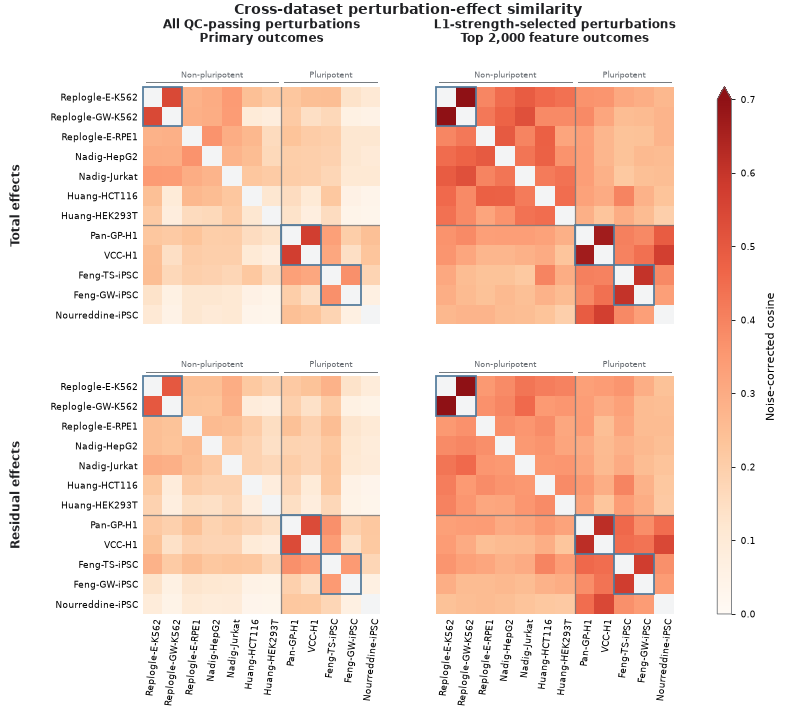

In [7]:
S1A_PANELS = {  # heatmap -> (effect, selection, axes bounds)
    "a": ("total", ALL_QC, (0.180, 0.545, 0.300, 0.333)),
    "b": ("total", L1_TOP2000, (0.550, 0.545, 0.300, 0.333)),
    "c": ("residual", ALL_QC, (0.180, 0.140, 0.300, 0.333)),
    "d": ("residual", L1_TOP2000, (0.550, 0.140, 0.300, 0.333)),
}
s1a_matrices = {
    panel: heatmap("Supplementary Fig. S1a", selection, effect)
    for panel, (effect, selection, _bounds) in S1A_PANELS.items()
}

use_panel_style(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "Liberation Sans"],
        "font.size": 6.5,
        "axes.titlesize": 8.0,
        "axes.labelsize": 7.0,
        "xtick.labelsize": 6.2,
        "ytick.labelsize": 6.2,
        "axes.linewidth": 0.6,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
    }
)
figure = plt.figure(figsize=(183.0 * MM, 165.0 * MM), facecolor="white")
cmap = colors.LinearSegmentedColormap.from_list("figure1_warm_similarity", WARM_PALETTE, N=256)
cmap.set_bad(MASKED_CELL_COLOR)
norm = colors.Normalize(vmin=0.0, vmax=0.70, clip=True)
positions = np.arange(len(ORDER))
for panel, (_effect, _selection, bounds) in S1A_PANELS.items():
    axis = figure.add_axes(bounds, label=f"panel_{panel}")
    axis.set_gid(panel)
    axis.set_facecolor(MASKED_CELL_COLOR)
    image = axis.imshow(
        np.ma.array(s1a_matrices[panel].to_numpy(float), mask=np.eye(len(ORDER), dtype=bool)),
        cmap=cmap,
        norm=norm,
        interpolation="nearest",
        aspect="equal",
        origin="upper",
    )
    axis.set_xticks(positions)
    axis.set_yticks(positions)
    if panel in {"c", "d"}:
        axis.set_xticklabels(LABELS)
        plt.setp(axis.get_xticklabels(), rotation=84, ha="right", rotation_mode="anchor", fontsize=6.2)
    else:
        axis.set_xticklabels([])
    if panel in {"a", "c"}:
        axis.set_yticklabels(LABELS)
        plt.setp(axis.get_yticklabels(), rotation=0, rotation_mode="anchor", ha="right", fontsize=6.2)
    else:
        axis.set_yticklabels([])
    axis.tick_params(axis="both", which="both", length=0, pad=3.0)
    axis.set_xlim(-0.5, len(ORDER) - 0.5)
    axis.set_ylim(len(ORDER) - 0.5, -0.5)
    axis.grid(False)
    for spine in axis.spines.values():
        spine.set_visible(False)

    # Context guides, related-dataset boxes and group labels.
    axis.axvline(N_NON_PLURIPOTENT - 0.5, color=SEPARATOR_COLOR, linewidth=0.85, alpha=0.78, zorder=5)
    axis.axhline(N_NON_PLURIPOTENT - 0.5, color=SEPARATOR_COLOR, linewidth=0.85, alpha=0.78, zorder=5)
    for start, width in RELATED_BLOCKS:
        axis.add_patch(
            Rectangle(
                (start - 0.5, start - 0.5),
                width,
                width,
                fill=False,
                edgecolor=BLOCK_OUTLINE_COLOR,
                linewidth=1.15,
                alpha=0.98,
                joinstyle="miter",
                zorder=7,
                clip_on=False,
            )
        )
    transform = axis.get_xaxis_transform()
    for left, right, center, label in CONTEXT_GROUPS:
        axis.plot(
            [left, right], [1.018, 1.018], transform=transform, color="#767B80", linewidth=0.65, clip_on=False
        )
        axis.text(
            center,
            1.030,
            label,
            transform=transform,
            ha="center",
            va="bottom",
            fontsize=5.4,
            color="#656A70",
            clip_on=False,
        )

for x, text in [
    (0.330, "All QC-passing perturbations\nPrimary outcomes"),
    (0.700, "L1-strength-selected perturbations\nTop 2,000 feature outcomes"),
]:
    figure.text(
        x,
        0.955,
        text,
        ha="center",
        va="center",
        fontsize=8.0,
        fontweight="bold",
        linespacing=1.12,
        color=TEXT_COLOR,
    )
for y, text in [(0.7115, "Total effects"), (0.3065, "Residual effects")]:
    figure.text(
        0.020,
        y,
        text,
        rotation=90,
        rotation_mode="anchor",
        ha="center",
        va="center",
        fontsize=8.0,
        fontweight="bold",
        color=TEXT_COLOR,
    )
figure.suptitle(
    "Cross-dataset perturbation-effect similarity",
    x=0.515,
    y=0.995,
    ha="center",
    va="top",
    fontsize=9.2,
    fontweight="bold",
    color=TEXT_COLOR,
)
colorbar_axis = figure.add_axes((0.905, 0.140, 0.018, 0.738), label="colorbar")
colorbar = figure.colorbar(
    image, cax=colorbar_axis, ticks=np.arange(0.0, 0.70 + 0.001, 0.1), extend="max", extendfrac=0.025
)
colorbar.set_label("Noise-corrected cosine", fontsize=7.2, labelpad=6.0)
colorbar.ax.tick_params(labelsize=6.0, length=2.5, width=0.55)
colorbar.outline.set_linewidth(0.55)
colorbar.outline.set_edgecolor("#6C7176")

show_inline(figure)
figure.savefig(FIGURES / "similarity_sensitivity.pdf", facecolor="white")
plt.close(figure)

## Supplementary Fig. S1b — noise-correction sensitivity (VCC subsampling)

Mean raw and SE-corrected cosine of each other dataset with VCC-H1 and with VCC-subsampled-H1, from the total-effect audit (panel C: L1-selected perturbations, primary outcomes). A dataset keeps the perturbations of its pair with VCC-H1 whose corrected-signal fraction is > 0.05 on both sides in both audits (unlike the matched matrices, only the two fractions are checked), and the same perturbations are taken from its pair with VCC-subsampled-H1. The raw cosine uses the outcomes with a finite effect and SE in both datasets; the corrected cosine is clipped to [-1, 1].

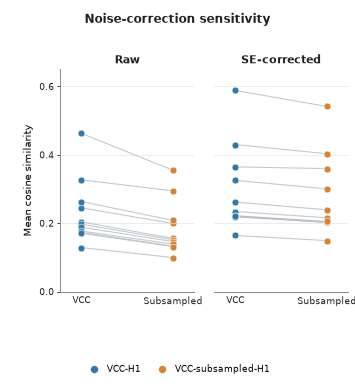

In [8]:
def vcc_pair(audit, dataset, vcc):
    """Panel C rows of the dataset-VCC pair (either order), sorted by perturbation."""
    first, second = audit["dataset_1"], audit["dataset_2"]
    in_pair = (first.eq(dataset) & second.eq(vcc)) | (first.eq(vcc) & second.eq(dataset))
    return audit.loc[audit["panel"].eq("C") & in_pair].set_index("perturbation").sort_index()


def fractions_pass(rows):
    return (
        rows["dataset_1_corrected_signal_fraction"].gt(MIN_SIGNAL_FRACTION)
        & rows["dataset_2_corrected_signal_fraction"].gt(MIN_SIGNAL_FRACTION)
    ).to_numpy()


def mean_cosines(rows):
    """Mean raw cosine and mean corrected cosine clipped to [-1, 1]."""
    raw = rows["raw_cosine_on_se_complete_outcomes"].to_numpy(float)
    corrected = np.clip(rows["would_be_noise_corrected_cosine_unclipped"].to_numpy(float), -1.0, 1.0)
    return raw.mean(), corrected.mean()


s1b_rows = []
for dataset in ORDER:
    if dataset == "VCC-H1":
        continue
    total_rows = vcc_pair(total_audit, dataset, "VCC-H1")
    residual_rows = vcc_pair(residual_audit, dataset, "VCC-H1")
    common = total_rows.index.intersection(residual_rows.index, sort=False)
    kept = common[fractions_pass(total_rows.loc[common]) & fractions_pass(residual_rows.loc[common])]
    raw_full, corrected_full = mean_cosines(total_rows.loc[kept])
    raw_subsampled, corrected_subsampled = mean_cosines(
        vcc_pair(total_audit, dataset, "VCC-subsampled-H1").loc[kept]
    )
    s1b_rows.append(
        {
            "dataset": dataset,
            "raw_mean_cosine_with_VCC_H1": raw_full,
            "raw_mean_cosine_with_VCC_subsampled_H1": raw_subsampled,
            "se_corrected_mean_cosine_with_VCC_H1": corrected_full,
            "se_corrected_mean_cosine_with_VCC_subsampled_H1": corrected_subsampled,
        }
    )
s1b = pd.DataFrame(s1b_rows)

S1B_VCC_COLOR = "#3478A8"
S1B_SUBSAMPLED_COLOR = "#D78135"


def draw_s1b_panel(axis, full_column, subsampled_column, title):
    full = s1b[full_column].to_numpy(float)
    subsampled = s1b[subsampled_column].to_numpy(float)
    x_positions = np.array([0.0, 1.0])
    for left, right in zip(full, subsampled, strict=True):
        axis.plot(
            x_positions,
            [left, right],
            color="#B8BEC4",
            linewidth=0.72,
            alpha=0.82,
            solid_capstyle="round",
            zorder=1,
        )
    for x, value, color in [(0.0, full, S1B_VCC_COLOR), (1.0, subsampled, S1B_SUBSAMPLED_COLOR)]:
        axis.scatter(
            np.full_like(value, x), value, s=20.0, color=color, edgecolors="white", linewidths=0.35, zorder=3
        )
    axis.set_title(title, pad=4.0, color=TEXT_COLOR, fontweight="bold")
    axis.set_xlim(-0.23, 1.23)
    axis.set_ylim(0.0, 0.65)
    axis.set_xticks(x_positions)
    axis.set_xticklabels(["VCC", "Subsampled"])
    axis.set_yticks([0.0, 0.2, 0.4, 0.6])
    axis.tick_params(axis="x", colors=TEXT_COLOR, length=0, pad=3.0)
    axis.tick_params(axis="y", colors=TEXT_COLOR, length=2.0, width=0.55, pad=2.0)
    axis.xaxis.grid(False)
    axis.yaxis.grid(True, color="#E7EAED", linewidth=0.55, zorder=0)
    axis.set_axisbelow(True)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    for side in ("left", "bottom"):
        axis.spines[side].set_color("#8A8F94")
        axis.spines[side].set_linewidth(0.65)


use_panel_style(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "Liberation Sans"],
        "font.size": 6.0,
        "axes.titlesize": 7.0,
        "axes.labelsize": 6.5,
        "xtick.labelsize": 5.8,
        "ytick.labelsize": 5.8,
        "legend.fontsize": 5.8,
        "axes.linewidth": 0.65,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
    }
)
figure, axes = plt.subplots(
    1, 2, figsize=(82.0 * MM, 90.0 * MM), sharex=True, sharey=True, gridspec_kw={"wspace": 0.15}
)
figure.patch.set_facecolor("white")
axes[0].set_gid("before")
axes[1].set_gid("after")
draw_s1b_panel(axes[0], "raw_mean_cosine_with_VCC_H1", "raw_mean_cosine_with_VCC_subsampled_H1", "Raw")
draw_s1b_panel(
    axes[1], "se_corrected_mean_cosine_with_VCC_H1", "se_corrected_mean_cosine_with_VCC_subsampled_H1", "SE-corrected"
)
axes[0].set_ylabel("Mean cosine similarity", labelpad=4.0)
axes[1].tick_params(axis="y", labelleft=False, left=False)
axes[1].spines["left"].set_visible(False)
figure.suptitle(
    "Noise-correction sensitivity", x=0.50, y=0.965, fontsize=8.0, fontweight="bold", color=TEXT_COLOR
)
legend_handles = [
    Line2D(
        [0],
        [0, 0],
        marker="o",
        linestyle="none",
        markersize=5.2,
        color=color,
        markerfacecolor=color,
        markeredgecolor="white",
        markeredgewidth=0.35,
        label=label,
    )
    for color, label in [(S1B_VCC_COLOR, "VCC-H1"), (S1B_SUBSAMPLED_COLOR, "VCC-subsampled-H1")]
]
figure.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.50, 0.018),
    ncol=2,
    frameon=False,
    handletextpad=0.45,
    columnspacing=1.4,
)
figure.subplots_adjust(left=0.17, right=0.98, top=0.82, bottom=0.25)

figure.canvas.draw()
show_inline(figure)
figure.savefig(FIGURES / "noise_correction_vcc_subsampling.pdf", facecolor="white")
plt.close(figure)

s1b.to_csv(DATA / "noise_correction_vcc_subsampling.csv", index=False)

## Supplementary Fig. S1c — L1 perturbation-strength concordance

Spearman ρ of `strength_L1` (`STRENGTH_SCORES`) between datasets, over the perturbations with a finite score in both (at least three); tested perturbations with zero strength stay in as tied weakest responses. Pan-GP-H1 is left out.

In [9]:
S1C_ORDER = [name for name in ORDER if name != "Pan-GP-H1"]
S1C_LABELS = S1C_ORDER

strength = pd.read_csv(STRENGTH_SCORES / "perturbation_strength_all_datasets.csv")
strength = strength.assign(dataset=strength["dataset"].map(paper_name)).dropna(subset=["strength_L1"])
scores = {
    dataset: strength.loc[strength["dataset"].eq(dataset), ["perturbation", "strength_L1"]]
    for dataset in S1C_ORDER
}
correlations = pd.DataFrame(np.eye(len(S1C_ORDER)), index=S1C_ORDER, columns=S1C_ORDER)
for left, right in combinations(S1C_ORDER, 2):
    shared = scores[left].merge(scores[right], on="perturbation", suffixes=("_left", "_right"))
    rho = np.nan
    if len(shared) >= 3:
        rho = float(stats.spearmanr(shared["strength_L1_left"], shared["strength_L1_right"]).statistic)
    correlations.loc[left, right] = correlations.loc[right, left] = rho

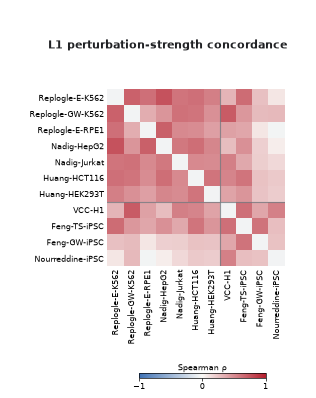

In [10]:
use_panel_style(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "Liberation Sans"],
        "font.size": 5.4,
        "axes.titlesize": 7.2,
        "xtick.labelsize": 5.2,
        "ytick.labelsize": 5.2,
        "axes.linewidth": 0.6,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
    }
)
figure = plt.figure(figsize=(73.0 * MM, 92.0 * MM), facecolor="white")
axis = figure.add_axes((0.34, 0.33, 0.56, 0.445), label="correlation_heatmap")
axis.set_gid("correlation_heatmap")
colorbar_axis = figure.add_axes((0.44, 0.050, 0.40, 0.014), label="colorbar")

cmap = colors.LinearSegmentedColormap.from_list(
    "strength_correlation", ("#3F72B5", "#FBFAF7", "#B51F2E"), N=256
)
cmap.set_bad("#F2F3F4")
values = correlations.to_numpy(float)
axis.set_facecolor("#F2F3F4")
image = axis.imshow(
    np.ma.array(values, mask=np.eye(len(values), dtype=bool)),
    cmap=cmap,
    norm=colors.TwoSlopeNorm(vmin=-1.0, vcenter=0.0, vmax=1.0),
    interpolation="nearest",
    aspect="equal",
    origin="upper",
)

positions = np.arange(len(S1C_ORDER))
axis.set_xticks(positions)
axis.set_yticks(positions)
axis.set_xticklabels(S1C_LABELS)
axis.set_yticklabels(S1C_LABELS)
plt.setp(axis.get_xticklabels(), rotation=90, rotation_mode="anchor", ha="right", va="center", fontsize=5.2)
plt.setp(axis.get_yticklabels(), rotation=0, rotation_mode="anchor", ha="right", fontsize=5.2)
axis.tick_params(axis="both", which="both", length=0, pad=2.2)
axis.set_xlim(-0.5, len(S1C_ORDER) - 0.5)
axis.set_ylim(len(S1C_ORDER) - 0.5, -0.5)
axis.grid(False)
for spine in axis.spines.values():
    spine.set_visible(False)
axis.axvline(N_NON_PLURIPOTENT - 0.5, color="#737A80", linewidth=0.75, alpha=0.78, zorder=5)
axis.axhline(N_NON_PLURIPOTENT - 0.5, color="#737A80", linewidth=0.75, alpha=0.78, zorder=5)

colorbar = figure.colorbar(image, cax=colorbar_axis, ticks=[-1.0, 0.0, 1.0], orientation="horizontal")
colorbar.outline.set_linewidth(0.45)
colorbar.ax.tick_params(axis="x", labelsize=5.2, length=1.8, width=0.45, pad=1.4)
colorbar.ax.xaxis.set_label_position("top")
colorbar.set_label("Spearman ρ", fontsize=5.5, labelpad=1.5)
figure.suptitle(
    "L1 perturbation-strength concordance",
    x=0.53,
    y=0.900,
    fontsize=7.2,
    fontweight="bold",
    color=TEXT_COLOR,
)

figure.canvas.draw()
show_inline(figure)
figure.savefig(FIGURES / "strength_rank_concordance.pdf", facecolor="white")
plt.close(figure)

masked_heatmap_table(correlations, S1C_LABELS).to_csv(DATA / "strength_rank_concordance_matrix.csv")